In [327]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [263]:
customerUrl = '../data/raw/customer.csv'
logisticsUrl = '../data/raw/logistics_performance.csv'
shipmentUrl = '../data/raw/shipment.csv'
customer = pd.read_csv(customerUrl)
logistics = pd.read_csv(logisticsUrl)
shipment = pd.read_csv(shipmentUrl)

In [264]:

# Función para convertir cualquier string a snake_case
def to_snake_case(df):
    df.columns = (df.columns
                  .str.strip()              # Elimina espacios al inicio y final
                  .str.lower()              # Todo a minúsculas
                  .str.replace(' ', '_')     # Espacios por guiones bajos
                  .str.replace('-', '_')     # Guiones medios por guiones bajos
                  .str.replace(r'[^\w\s]', '', regex=True) # Elimina símbolos raros
                 )
    return df

# Aplicarlo a tus tres DataFrames
customer = to_snake_case(customer)
logistics = to_snake_case(logistics)
shipment = to_snake_case(shipment)

# Verificar el resultado
print(logistics.columns)
print(customer.columns)
print(shipment.columns)

Index(['date', 'region', 'carrier', 'shipments_processed', 'delay_hours_avg',
       'fuel_price_usd_per_barrel', 'warehouse_utilization_percent',
       'damage_claims_count'],
      dtype='object')
Index(['customer_id', 'acquisition_date', 'acquisition_cost_usd',
       'market_segment', 'supplier_id', 'order_id', 'order_date',
       'order_value_usd', 'payment_date', 'satisfaction_score',
       'support_tickets', 'lead_time_days'],
      dtype='object')
Index(['shipment_id', 'type', 'date', 'product_category', 'origin',
       'o_country', 'destination', 'd_country', 'value', 'freight_cost',
       'customs_clearance_time_days', 'delivery_status'],
      dtype='object')


##  customer

In [265]:
customer.head()

,customer_id,acquisition_date,acquisition_cost_usd,market_segment,supplier_id,order_id,order_date,order_value_usd,payment_date,satisfaction_score,support_tickets,lead_time_days
0,CUST-001,2024-01-05,850,North America,SUP-A,ORD-1001,2024-01-15,12500,2024-02-18,4,1,14
1,CUST-002,2024-01-06,920,Europe,SUP-B,ORD-1002,2024-01-18,8500,2024-02-25,5,0,16
2,CUST-003,2024-01-07,880,Asia-Pacific,SUP-C,ORD-1003,2024-01-20,21000,2024-03-01,4,2,15
3,CUST-004,2024-01-08,790,North America,SUP-A,ORD-1004,2024-01-22,7500,2024-02-28,3,1,13
4,CUST-005,2024-01-09,950,Europe,SUP-D,ORD-1005,2024-01-25,15000,2024-03-05,5,0,12


In [266]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           750 non-null    object
 1   acquisition_date      750 non-null    object
 2   acquisition_cost_usd  750 non-null    int64 
 3   market_segment        750 non-null    object
 4   supplier_id           750 non-null    object
 5   order_id              750 non-null    object
 6   order_date            750 non-null    object
 7   order_value_usd       750 non-null    int64 
 8   payment_date          750 non-null    object
 9   satisfaction_score    750 non-null    int64 
 10  support_tickets       750 non-null    int64 
 11  lead_time_days        750 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 70.4+ KB


In [267]:
customer.isnull().sum()

customer_id             0
acquisition_date        0
acquisition_cost_usd    0
market_segment          0
supplier_id             0
order_id                0
order_date              0
order_value_usd         0
payment_date            0
satisfaction_score      0
support_tickets         0
lead_time_days          0
dtype: int64

In [270]:
customer.describe()

,acquisition_cost_usd,order_value_usd,satisfaction_score,support_tickets,lead_time_days
count,750.000000,750.000000,750.000000,750.000000,750.000000
mean,880.826667,15142.000000,4.178667,0.597333,14.693333
std,47.625703,5590.573198,0.712335,0.712650,1.839874
min,790.000000,5000.000000,3.000000,0.000000,12.000000
25%,840.000000,10000.000000,4.000000,0.000000,13.000000
50%,880.000000,15000.000000,4.000000,0.000000,14.000000
75%,920.000000,20000.000000,5.000000,1.000000,16.000000
max,960.000000,25000.000000,5.000000,3.000000,20.000000


In [271]:
customer.describe(  include='object')

,customer_id,acquisition_date,market_segment,supplier_id,order_id,order_date,payment_date
count,750,750,750,750,750,750,750
unique,750,750,5,7,750,750,750
top,CUST-750,2026-01-24,North America,SUP-A,ORD-1750,2029-04-12,2029-05-22
freq,1,1,189,108,1,1,1


In [272]:
customer.duplicated().sum()

np.int64(0)

In [274]:
print(customer.nunique())
print(f"Number of duplicated rows: {customer.duplicated().sum()}")

customer_id             750
acquisition_date        750
acquisition_cost_usd     18
market_segment            5
supplier_id               7
order_id                750
order_date              750
order_value_usd          41
payment_date            750
satisfaction_score        3
support_tickets           4
lead_time_days            9
dtype: int64
Number of duplicated rows: 0


In [275]:
date_columns = ['acquisition_date','order_date','payment_date']
for col in date_columns:
    customer[col] = pd.to_datetime(customer[col], errors='coerce')

In [276]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           750 non-null    object        
 1   acquisition_date      750 non-null    datetime64[ns]
 2   acquisition_cost_usd  750 non-null    int64         
 3   market_segment        750 non-null    object        
 4   supplier_id           750 non-null    object        
 5   order_id              750 non-null    object        
 6   order_date            750 non-null    datetime64[ns]
 7   order_value_usd       750 non-null    int64         
 8   payment_date          750 non-null    datetime64[ns]
 9   satisfaction_score    750 non-null    int64         
 10  support_tickets       750 non-null    int64         
 11  lead_time_days        750 non-null    int64         
dtypes: datetime64[ns](3), int64(5), object(4)
memory usage: 70.4+ KB


In [277]:
date_columns = ['market_segment','supplier_id', 'satisfaction_score','acquisition_cost_usd', 'lead_time_days','support_tickets','order_value_usd']
for col in date_columns:
    print(f"Unique values in {col}: {customer[col].unique()}")

Unique values in market_segment: ['North America' 'Europe' 'Asia-Pacific' 'Middle East' 'Africa']
Unique values in supplier_id: ['SUP-A' 'SUP-B' 'SUP-C' 'SUP-D' 'SUP-E' 'SUP-F' 'SUP-G']
Unique values in satisfaction_score: [4 5 3]
Unique values in acquisition_cost_usd: [850 920 880 790 950 830 910 860 900 810 890 930 840 870 960 820 940 800]
Unique values in lead_time_days: [14 16 15 13 12 17 18 19 20]
Unique values in support_tickets: [1 0 2 3]
Unique values in order_value_usd: [12500  8500 21000  7500 15000  9500 18000 11000 13500  6500 16000 22000
  8000 17500 10500 19000  5500 14000 11500 24000  9000 16500 20000  7000
 10000 23000 14500 21500 18500 17000 12000  6000 19500 22500 13000 15500
 20500 25000  5000 23500 24500]


In [278]:
customer.describe(include='all')

,customer_id,acquisition_date,acquisition_cost_usd,market_segment,supplier_id,order_id,order_date,order_value_usd,payment_date,satisfaction_score,support_tickets,lead_time_days
count,750,750,750.000000,750,750,750,750,750.000000,750,750.000000,750.000000,750.000000
unique,750,NaN,NaN,5,7,750,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST-750,NaN,NaN,North America,SUP-A,ORD-1750,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,189,108,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2025-01-14 10:14:24,880.826667,NaN,NaN,NaN,2026-08-29 05:28:19.200000,15142.000000,2026-10-08 07:17:45.600000,4.178667,0.597333,14.693333
min,NaN,2024-01-05 00:00:00,790.000000,NaN,NaN,NaN,2024-01-15 00:00:00,5000.000000,2024-02-18 00:00:00,3.000000,0.000000,12.000000
25%,NaN,2024-07-11 06:00:00,840.000000,NaN,NaN,NaN,2025-05-08 12:00:00,10000.000000,2025-06-17 12:00:00,4.000000,0.000000,13.000000
50%,NaN,2025-01-14 12:00:00,880.000000,NaN,NaN,NaN,2026-08-29 00:00:00,15000.000000,2026-10-08 00:00:00,4.000000,0.000000,14.000000
75%,NaN,2025-07-20 18:00:00,920.000000,NaN,NaN,NaN,2027-12-19 12:00:00,20000.000000,2028-01-28 12:00:00,5.000000,1.000000,16.000000
max,NaN,2026-01-24 00:00:00,960.000000,NaN,NaN,NaN,2029-04-12 00:00:00,25000.000000,2029-05-22 00:00:00,5.000000,3.000000,20.000000


* adqusiocion de clientes es muy uniforme todos se mantienen por un rango de 790 y 960 podria sicnificar que las que el marketin esta vien estructurado 
* los pedidos son predecibles ya que tienen  1.8  de desvviacion (bueno ya que  se le puede decir al clientee cuanto se le puede demorar ) normalmente dura 14 dias 
* mercado principal es northe america podri ser bueno para un analisis mas detallado 

### graficas

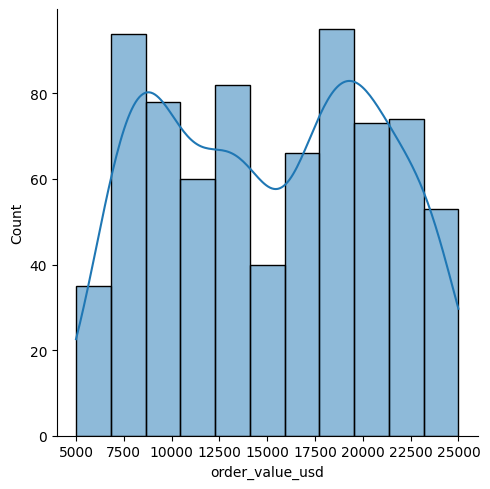

In [280]:
sns.displot(data=customer, x='order_value_usd', kde=True)

* Curiosamente media estadistica que vimos antes era de 15.142 casi nadie compra
bimodal
* 7,500 - 9,000 pedidos de bajo valor. Podrían ser clientes medianos 
* 17,500 - 20,000 compras granedes o puede ser producto de alto valor 

<Axes: xlabel='acquisition_cost_usd', ylabel='market_segment'>

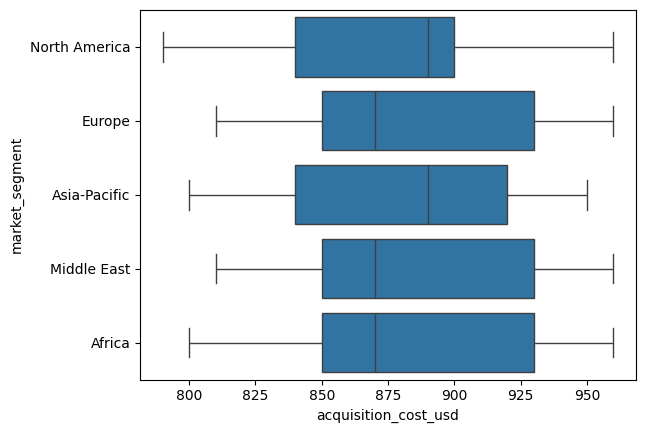

In [281]:
sns.boxplot(data=customer , x='acquisition_cost_usd', y='market_segment')

 * Asia la mayor parte de personas de 950 segun la mediana siendo que un mercado caro 
* otra parte en norteamerica tambien tenemos que gran parte para adquisicion de clientes va 850 apesar de que su tope de adquisiocion es mas bajo sin embargo es un mecado es predecible 
* Europe, Middle East y Africa mercados más volatiles un cliente te puede salir relativamente barato o muy costoso de la nada.



<Axes: xlabel='acquisition_cost_usd', ylabel='order_value_usd'>

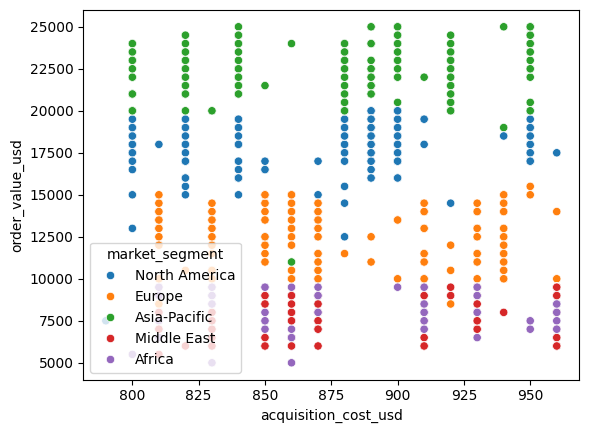

In [283]:
sns.scatterplot(data=customer , x='acquisition_cost_usd',y='order_value_usd', hue='market_segment')

* asi  y norte america dominan $17,500 a $25,000 el retorno es masivo
* middle east y africa hay clientes que cuenstan  mas de 900 pero su retorno o compra es muy bajo es necesario mirar el mercado para ver que tan rentable es 


<Axes: xlabel='market_segment', ylabel='order_value_usd'>

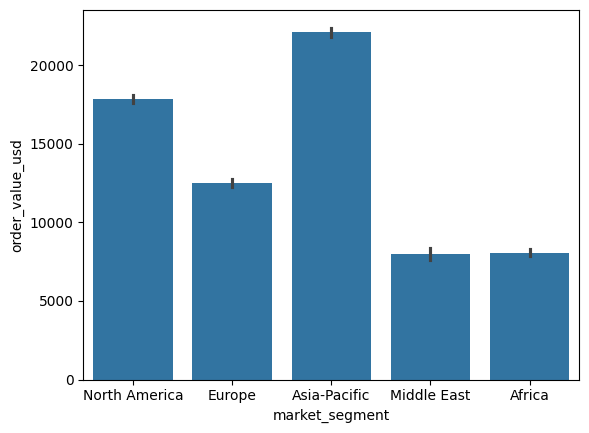

In [284]:
sns.barplot(data=customer, x='market_segment', y='order_value_usd', estimator='mean')

* Asia-Pacific ticket promedio mas alto
* Middle East y Africa  prácticamente empatados

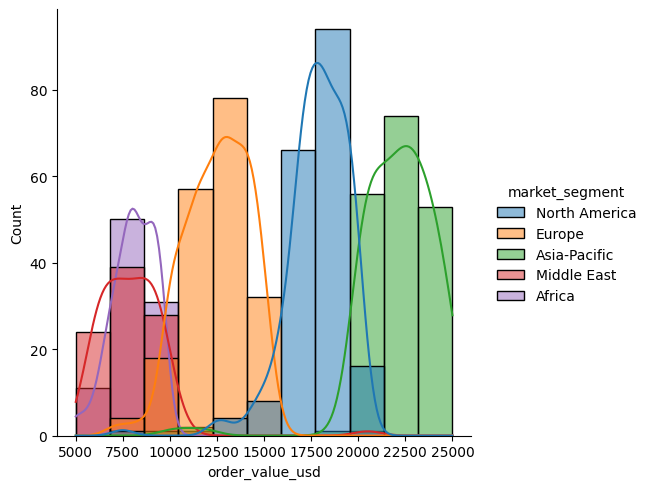

In [285]:
sns.displot(data=customer, x='order_value_usd', hue='market_segment', kde=True)

* mercado está naturalmente fragmentado.
* compra por debajo de los $15,000 USD
* pendiente del costo de danos a productos tan caros de noth america u asia 

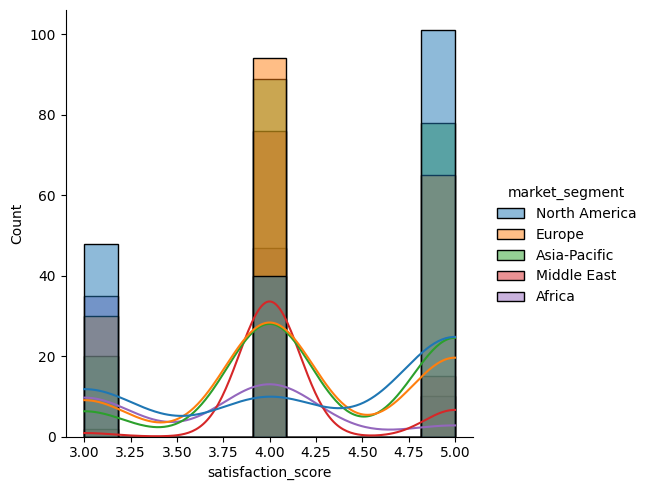

In [286]:
sns.displot(data=customer, x='satisfaction_score', hue='market_segment', kde=True)

* concentran la gran mayoría de las calificaciones perfectas no seria raro que este mercado sea de maxima prioridad mejorando el servicio
* en genral la emrpesa cumple con las espectativas 
* hay que analisar el 3 de north america ya que es de los mercados mas importantes y rentables 


<Axes: >

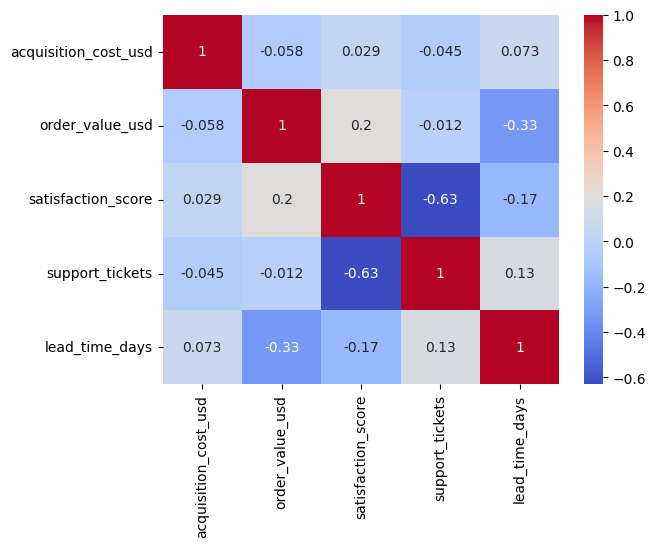

In [287]:
corr = customer.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

## logistics

In [288]:
logistics.head()

,date,region,carrier,shipments_processed,delay_hours_avg,fuel_price_usd_per_barrel,warehouse_utilization_percent,damage_claims_count
0,2024-06-01,North America,FastShip,1500,2.5,78.2,85,5
1,2024-06-01,Europe,GlobalConnect,1200,1.8,79.5,75,2
2,2024-06-01,Asia-Pacific,OceanExpress,2100,4.1,81.1,92,12
3,2024-06-01,North America,ReliableLogistics,900,1.2,78.2,60,1
4,2024-06-02,North America,FastShip,1450,2.8,78.5,86,6


In [289]:
logistics.describe()

,shipments_processed,delay_hours_avg,fuel_price_usd_per_barrel,warehouse_utilization_percent,damage_claims_count
count,100.000000,100.000000,100.00000,100.000000,100.00000
mean,1461.200000,2.451000,82.74800,78.000000,5.72000
std,472.665513,1.263353,2.48866,12.164695,5.48106
min,850.000000,0.900000,78.20000,58.000000,0.00000
25%,1105.000000,1.475000,80.85000,70.250000,2.00000
50%,1365.000000,2.050000,82.75000,80.000000,3.50000
75%,1715.000000,3.275000,84.60000,87.750000,7.75000
max,2370.000000,5.000000,88.30000,94.000000,20.00000


* mirar si elocupacion promedio afecta los productos ya que el  75% de las veces se usa el 87 del almacen  alta saturacion 
* 50% de las veces tienes 3.5 reclamos
* hay dias que los reclamos se elevan hasta 20.     mirar que rutas son o que lo afecta punto de mejora  
* retraso promedio de 2.45 horas  pero hay unos de 5 mirar  si puede generar perdias de ventas 
*  factura de combustible tiene volatilidad de 2.5

In [290]:
logistics.describe(include='object')

,date,region,carrier
count,100,100,100
unique,25,3,4
top,2024-06-01,North America,FastShip
freq,4,50,25


In [291]:
logistics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           100 non-null    object 
 1   region                         100 non-null    object 
 2   carrier                        100 non-null    object 
 3   shipments_processed            100 non-null    int64  
 4   delay_hours_avg                100 non-null    float64
 5   fuel_price_usd_per_barrel      100 non-null    float64
 6   warehouse_utilization_percent  100 non-null    int64  
 7   damage_claims_count            100 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 6.4+ KB


In [292]:
logistics.duplicated().sum()

np.int64(0)

In [293]:
print(logistics.nunique())
print(f"Number of duplicated rows: {logistics.duplicated().sum()}")

date                             25
region                            3
carrier                           4
shipments_processed              66
delay_hours_avg                  35
fuel_price_usd_per_barrel        74
warehouse_utilization_percent    20
damage_claims_count              19
dtype: int64
Number of duplicated rows: 0


In [294]:
print(logistics.isnull().sum())

date                             0
region                           0
carrier                          0
shipments_processed              0
delay_hours_avg                  0
fuel_price_usd_per_barrel        0
warehouse_utilization_percent    0
damage_claims_count              0
dtype: int64


In [295]:
logistics['date'] = pd.to_datetime(logistics['date'], errors='coerce')

In [296]:
date_columns = ['region','carrier', 'damage_claims_count','warehouse_utilization_percent']
for col in date_columns:
    print(f"Unique values in {col}: {logistics[col].unique()}")

Unique values in region: ['North America' 'Europe' 'Asia-Pacific']
Unique values in carrier: ['FastShip' 'GlobalConnect' 'OceanExpress' 'ReliableLogistics']
Unique values in damage_claims_count: [ 5  2 12  1  6  3 15  0  4 11 18  7 10 14 16 13 19 17 20]
Unique values in warehouse_utilization_percent: [85 75 92 60 86 74 93 61 84 76 91 59 83 73 94 62 87 77 90 58]


In [297]:
logistics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           100 non-null    datetime64[ns]
 1   region                         100 non-null    object        
 2   carrier                        100 non-null    object        
 3   shipments_processed            100 non-null    int64         
 4   delay_hours_avg                100 non-null    float64       
 5   fuel_price_usd_per_barrel      100 non-null    float64       
 6   warehouse_utilization_percent  100 non-null    int64         
 7   damage_claims_count            100 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 6.4+ KB


### graficas

<Axes: xlabel='region', ylabel='delay_hours_avg'>

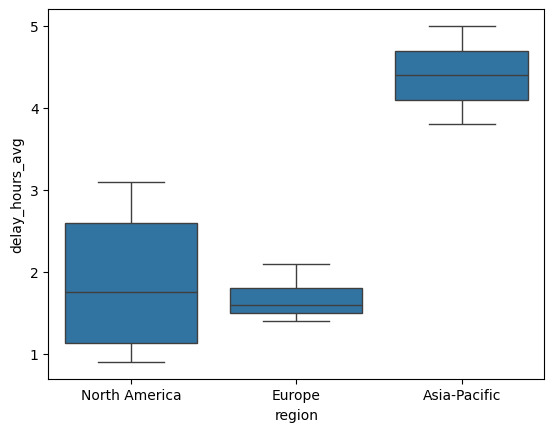

In [298]:
sns.boxplot(data=logistics, x="region", y="delay_hours_avg")

Los retrasos en Asia-Pacific están completamente desfasados hacia arriba (mirar porque tanto retraso si asia es el mejor cliente compra producto mas caro )
noteamerica es muy incosnistente  puede cer por eso que tenga la peor calificacion en satisfaccion 

<Axes: xlabel='carrier', ylabel='damage_claims_count'>

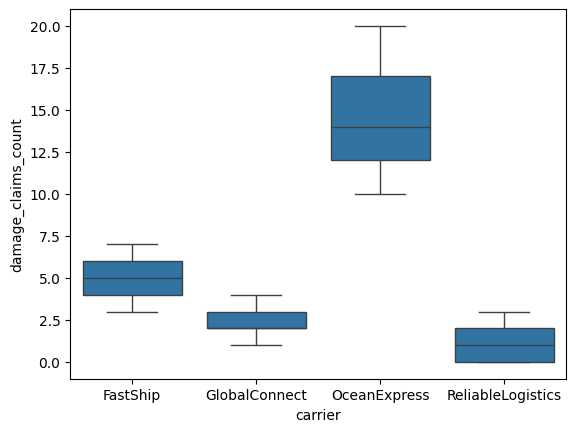

In [299]:
sns.boxplot(data=logistics, x="carrier", y="damage_claims_count")

OceanExpress es un peligro los demas transportistas mantienen sus incidentes controlados por debajo de los 7 reclamos, este operador multiplica las pérdidas materiales.
ceanExpress sea el transportista asignado a esa ruta marítima. Están entregando tarde y, además, destrozando la mercancía

<Axes: >

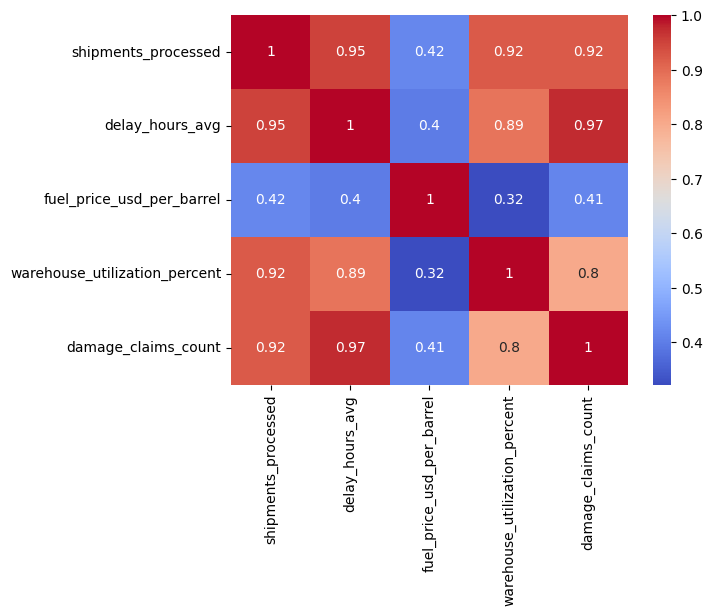

In [301]:
corr = logistics.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='shipments_processed', ylabel='delay_hours_avg'>

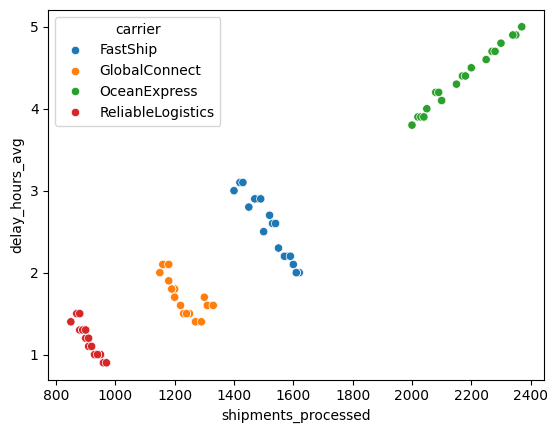

In [302]:
sns.scatterplot(
    data=logistics,
    x="shipments_processed",
    y="delay_hours_avg",
    hue="carrier"
)

OceanExpress sus procesos colapsan bajo volumen
FastShip y GlobalConnect tendencia decendente mayor envio menos retraso
Insight  para cargas urgentes que requieran

<Axes: xlabel='shipments_processed', ylabel='delay_hours_avg'>

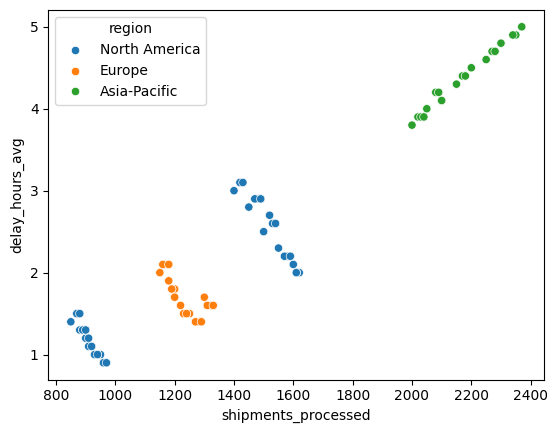

In [303]:
sns.scatterplot(
    data=logistics,
    x="shipments_processed",
    y="delay_hours_avg",
    hue="region"
)

cada transportista opera de forma exclusiva en una sola region
manejando entre 800 y 1000 envíos con retrasos minimo aumenta el retraso  1400 y 1600

<Axes: xlabel='warehouse_utilization_percent', ylabel='damage_claims_count'>

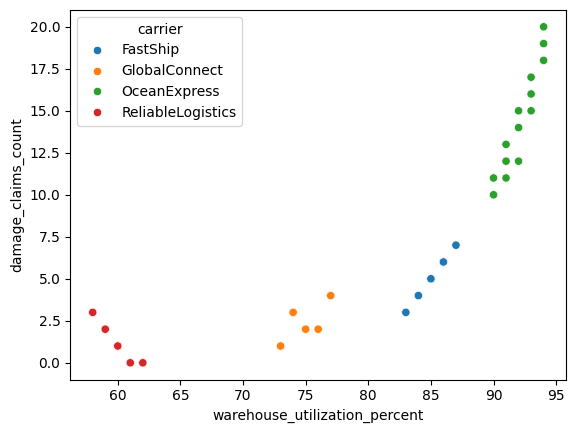

In [304]:
sns.scatterplot(
    data=logistics,
    x="warehouse_utilization_percent",
    y="damage_claims_count",
    hue="carrier"
)

OceanExpress se concentran exclusivamente en la zona crítica: entre 90% y 94% de utilización. En ese micro-rango, los daños se disparan exponencialmente,

<Axes: xlabel='warehouse_utilization_percent', ylabel='damage_claims_count'>

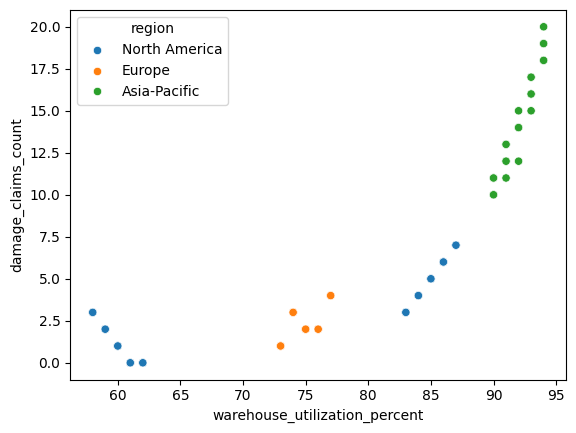

In [305]:
sns.scatterplot(
    data=logistics,
    x="warehouse_utilization_percent",
    y="damage_claims_count",
    hue="region"
)

problema no es solo del transportista OceanExpress, sino de la infraestructura en Asia-Pacífico 

## shipment

In [306]:
shipment.head(10)

,shipment_id,type,date,product_category,origin,o_country,destination,d_country,value,freight_cost,customs_clearance_time_days,delivery_status
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250.0,2.1,On-Time
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000.0,3.5,On-Time
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250.0,1.8,On-Time
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500.0,4.2,Delayed
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750.0,2.5,On-Time
5,SHP-2024-0006,Import,2024-01-07,Consumer Goods,Ho Chi Minh City,Vietnam,Mumbai,India,60000,3000.0,2.0,On-Time
6,SHP-2024-0007,Export,2024-01-08,Textiles,Mumbai,India,Dubai,UAE,75000,3750.0,1.5,On-Time
7,SHP-2024-0008,Import,2024-01-09,Electronics,Seoul,South Korea,Mumbai,India,180000,9000.0,3.8,On-Time
8,SHP-2024-0009,Export,2024-01-10,Industrial Equipment,Mumbai,India,Singapore,65000,3250,2.2,On-Time,NaN
9,SHP-2024-0010,Import,2024-01-11,Textiles,Dhaka,Bangladesh,Mumbai,India,90000,4500.0,2.7,On-Time


In [307]:
shipment.describe(include=['object'])

,shipment_id,type,date,product_category,origin,o_country,destination,d_country,customs_clearance_time_days,delivery_status
count,728,728,728,728,728,728,728,728,728,704
unique,728,2,728,4,16,15,15,37,47,2
top,SHP-2025-0364,Export,2025-12-31,Electronics,Mumbai,India,Mumbai,India,3.5,On-Time
freq,1,364,1,194,364,364,364,364,24,594


In [308]:
print(shipment.isnull().sum())

shipment_id                     0
type                            0
date                            0
product_category                0
origin                          0
o_country                       0
destination                     0
d_country                       0
value                           0
freight_cost                    0
customs_clearance_time_days     0
delivery_status                24
dtype: int64


In [309]:
shipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   shipment_id                  728 non-null    object 
 1   type                         728 non-null    object 
 2   date                         728 non-null    object 
 3   product_category             728 non-null    object 
 4   origin                       728 non-null    object 
 5   o_country                    728 non-null    object 
 6   destination                  728 non-null    object 
 7   d_country                    728 non-null    object 
 8   value                        728 non-null    int64  
 9   freight_cost                 728 non-null    float64
 10  customs_clearance_time_days  728 non-null    object 
 11  delivery_status              704 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 68.4+ KB


In [310]:
def is_texto(val):
    if pd.isna(val): return False
    try:
        float(val)
        return False
    except ValueError:
        return True
mask_corrida = (shipment['delivery_status'].isna()) & (shipment['customs_clearance_time_days'].apply(is_texto))

# El estatus de entrega está atrapado en la columna de aduanas
shipment.loc[mask_corrida, 'delivery_status'] = shipment.loc[mask_corrida, 'customs_clearance_time_days']
# Los días de aduana están atrapados en el costo de flete
shipment.loc[mask_corrida, 'customs_clearance_time_days'] = shipment.loc[mask_corrida, 'freight_cost']

# El costo de flete está atrapado en el valor (value)
shipment.loc[mask_corrida, 'freight_cost'] = shipment.loc[mask_corrida, 'value']

# El valor (value) está atrapado en el país de destino (d_country)
shipment.loc[mask_corrida, 'value'] = shipment.loc[mask_corrida, 'd_country']
# Como d_country estaba vacío, el país quedó en 'destination'
shipment.loc[mask_corrida, 'd_country'] = shipment.loc[mask_corrida, 'destination']

/tmp/ipykernel_6717/1156294403.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['65000' '69000' '72000' '75000' '78000' '81000' '84000' '87000' '90000'
 '93000' '96000' '99000' '66500' '70500' '73500' '76500' '79500' '82500'
 '85500' '88500' '91500' '94500' '97500' '100500']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  shipment.loc[mask_corrida, 'value'] = shipment.loc[mask_corrida, 'd_country']


In [311]:
shipment.head(10)

,shipment_id,type,date,product_category,origin,o_country,destination,d_country,value,freight_cost,customs_clearance_time_days,delivery_status
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250.0,2.1,On-Time
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000.0,3.5,On-Time
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250.0,1.8,On-Time
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500.0,4.2,Delayed
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750.0,2.5,On-Time
5,SHP-2024-0006,Import,2024-01-07,Consumer Goods,Ho Chi Minh City,Vietnam,Mumbai,India,60000,3000.0,2.0,On-Time
6,SHP-2024-0007,Export,2024-01-08,Textiles,Mumbai,India,Dubai,UAE,75000,3750.0,1.5,On-Time
7,SHP-2024-0008,Import,2024-01-09,Electronics,Seoul,South Korea,Mumbai,India,180000,9000.0,3.8,On-Time
8,SHP-2024-0009,Export,2024-01-10,Industrial Equipment,Mumbai,India,Singapore,Singapore,65000,3250.0,2.2,On-Time
9,SHP-2024-0010,Import,2024-01-11,Textiles,Dhaka,Bangladesh,Mumbai,India,90000,4500.0,2.7,On-Time


In [312]:
if 'customs_clearance_time_days' in shipment.columns:
    shipment['customs_clearance_time_days'] = pd.to_numeric(shipment['customs_clearance_time_days'], errors='coerce')

In [313]:
shipment.describe()

,freight_cost,customs_clearance_time_days
count,728.000000,728.000000
mean,7121.325549,3.710989
std,4181.258259,0.964937
min,1750.000000,1.500000
25%,3893.750000,3.000000
50%,5600.000000,3.700000
75%,9712.500000,4.500000
max,20750.000000,5.900000


In [314]:
print(shipment.nunique())
print(f"Number of duplicated rows: {shipment.duplicated().sum()}")

shipment_id                    728
type                             2
date                           728
product_category                 4
origin                          16
o_country                       15
destination                     15
d_country                       14
value                          318
freight_cost                   294
customs_clearance_time_days     45
delivery_status                  2
dtype: int64
Number of duplicated rows: 0


In [315]:
date_columns = ['type','product_category', 'origin','o_country','destination','delivery_status','d_country']
for col in date_columns:
    print(f"Unique values in {col}: {shipment[col].unique()}")

Unique values in type: ['Export' 'Import']
Unique values in product_category: ['Electronics' 'Textiles' 'Consumer Goods' 'Industrial Equipment']
Unique values in origin: ['Mumbai' 'Shanghai' 'Hamburg' 'Ho Chi Minh City' 'Seoul' 'Dhaka' 'Taipei'
 'Bangkok' 'Genoa' 'Istanbul' 'San Francisco' 'Jakarta' 'Yokohama'
 'Manila' 'Helsinki' 'Busan']
Unique values in o_country: [' India' ' China' ' Germany' ' Vietnam' ' South Korea' ' Bangladesh'
 ' Taiwan' ' Thailand' ' Italy' ' Turkey' ' USA' ' Indonesia' ' Japan'
 ' Philippines' ' Finland']
Unique values in destination: ['New York' 'Mumbai' 'London' 'Tokyo' 'Dubai' 'Singapore' 'Sydney'
 'Rotterdam' 'Los Angeles' 'Jeddah' 'Durban' 'Lagos' 'Mexico City' 'Cairo'
 'Rio de Janeiro']
Unique values in delivery_status: ['On-Time' 'Delayed']
Unique values in d_country: [' USA' ' India' ' UK' ' Japan' ' UAE' 'Singapore' ' Australia'
 ' Netherlands' ' Saudi Arabia' ' South Africa' ' Nigeria' ' Mexico'
 ' Egypt' ' Brazil']


In [316]:
shipment['date'] = pd.to_datetime(shipment['date'], errors='coerce')
shipment['value'] = pd.to_numeric(shipment['value'], errors='coerce')

In [317]:
shipment.head(9)

,shipment_id,type,date,product_category,origin,o_country,destination,d_country,value,freight_cost,customs_clearance_time_days,delivery_status
0,SHP-2024-0001,Export,2024-01-02,Electronics,Mumbai,India,New York,USA,85000,4250.0,2.1,On-Time
1,SHP-2024-0002,Import,2024-01-03,Textiles,Shanghai,China,Mumbai,India,120000,6000.0,3.5,On-Time
2,SHP-2024-0003,Export,2024-01-04,Consumer Goods,Mumbai,India,London,UK,45000,2250.0,1.8,On-Time
3,SHP-2024-0004,Import,2024-01-05,Industrial Equipment,Hamburg,Germany,Mumbai,India,250000,12500.0,4.2,Delayed
4,SHP-2024-0005,Export,2024-01-06,Electronics,Mumbai,India,Tokyo,Japan,95000,4750.0,2.5,On-Time
5,SHP-2024-0006,Import,2024-01-07,Consumer Goods,Ho Chi Minh City,Vietnam,Mumbai,India,60000,3000.0,2.0,On-Time
6,SHP-2024-0007,Export,2024-01-08,Textiles,Mumbai,India,Dubai,UAE,75000,3750.0,1.5,On-Time
7,SHP-2024-0008,Import,2024-01-09,Electronics,Seoul,South Korea,Mumbai,India,180000,9000.0,3.8,On-Time
8,SHP-2024-0009,Export,2024-01-10,Industrial Equipment,Mumbai,India,Singapore,Singapore,65000,3250.0,2.2,On-Time


In [318]:
shipment.duplicated().sum()

np.int64(0)

In [319]:
shipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   shipment_id                  728 non-null    object        
 1   type                         728 non-null    object        
 2   date                         728 non-null    datetime64[ns]
 3   product_category             728 non-null    object        
 4   origin                       728 non-null    object        
 5   o_country                    728 non-null    object        
 6   destination                  728 non-null    object        
 7   d_country                    728 non-null    object        
 8   value                        728 non-null    int64         
 9   freight_cost                 728 non-null    float64       
 10  customs_clearance_time_days  728 non-null    float64       
 11  delivery_status              728 non-null    

In [320]:
shipment['freight_cost'] = pd.to_numeric(shipment['freight_cost'], errors='coerce')

In [321]:
shipment.describe()

,date,value,freight_cost,customs_clearance_time_days
count,728,728.000000,728.000000,728.000000
mean,2024-12-31 22:05:16.483516416,142426.510989,7121.325549,3.710989
min,2024-01-02 00:00:00,35000.000000,1750.000000,1.500000
25%,2024-07-02 18:00:00,77875.000000,3893.750000,3.000000
50%,2025-01-01 00:00:00,112000.000000,5600.000000,3.700000
75%,2025-07-02 06:00:00,194250.000000,9712.500000,4.500000
max,2025-12-31 00:00:00,415000.000000,20750.000000,5.900000
std,NaN,83625.165177,4181.258259,0.964937


* el valor del envio es el 5% dela mercancia 
* el 75% de los envios se liberan de aduanas a los 4.5dias ademas segun la desviacion enstadar es de 0.96 lo cual es constante en todo lado por lo caul es  posible tener un estandar 

In [322]:
shipment.describe(include='object')

,shipment_id,type,product_category,origin,o_country,destination,d_country,delivery_status
count,728,728,728,728,728,728,728,728
unique,728,2,4,16,15,15,14,2
top,SHP-2025-0364,Export,Electronics,Mumbai,India,Mumbai,India,On-Time
freq,1,364,194,364,364,364,364,612


* 50%  todos tus envíos globales se mueven en la ruta interna o externa de la India (Mumbai)
* La electrónica principal carga segun lo anteior es rasonable porque tenemos productos de tanalto valor
* Tu tasa de efectividad de entregas global 84.06
* 16% de retrasos representa tu oportunidad de mejora

### graficas

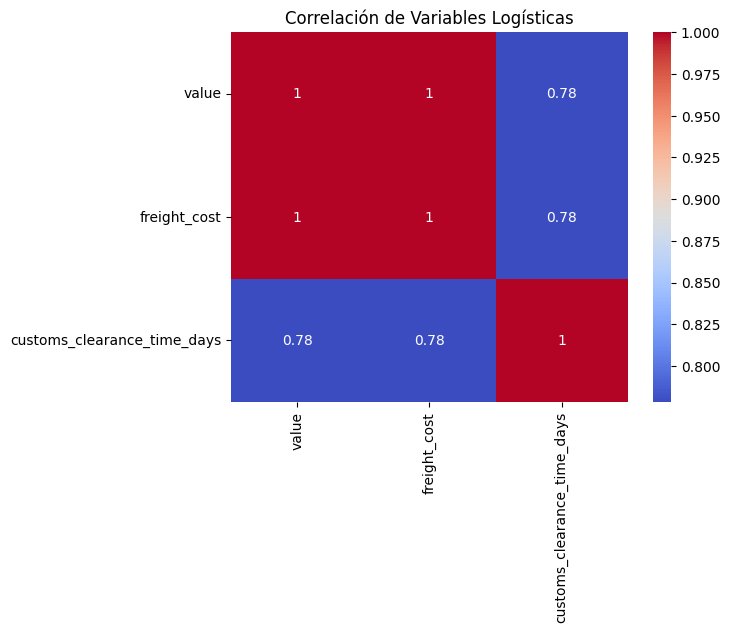

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecciona solo columnas numéricas
corr = shipment.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlación de Variables Logísticas")
plt.show()

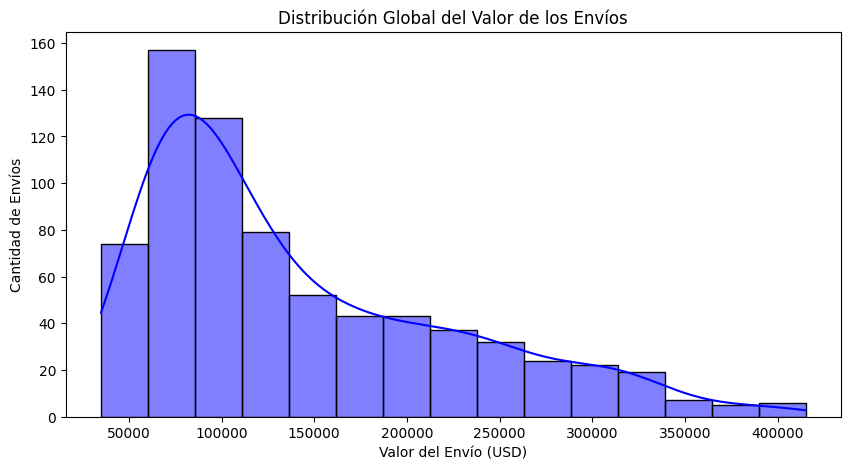

In [324]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=shipment, x='value', kde=True, color='blue')
plt.title('Distribución Global del Valor de los Envíos')
plt.xlabel('Valor del Envío (USD)')
plt.ylabel('Cantidad de Envíos')
plt.show()

* los embarques se concentran en el rango de 50000 a 120000  con un pico masivo muy cerca de los 75000  y luego decae suavemente con unos pocos envios exclusivos que llegan hasta los 415000 

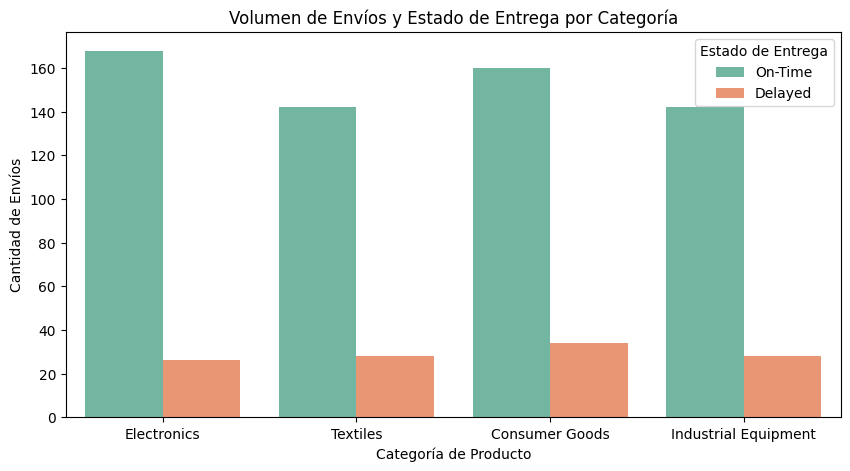

In [325]:
plt.figure(figsize=(10, 5))
sns.countplot(data=shipment, x='product_category', hue='delivery_status', palette='Set2')
plt.title('Volumen de Envíos y Estado de Entrega por Categoría')
plt.xlabel('Categoría de Producto')
plt.ylabel('Cantidad de Envíos')
plt.legend(title='Estado de Entrega')
plt.show()

* Consumer Goods Es la categoria con mayor cantidad de retrasos
* Electronics reina en volumen total de envios a tiempo 

/tmp/ipykernel_6717/4269706868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipment, x='d_country', y='customs_clearance_time_days', errorbar=None, palette='viridis')


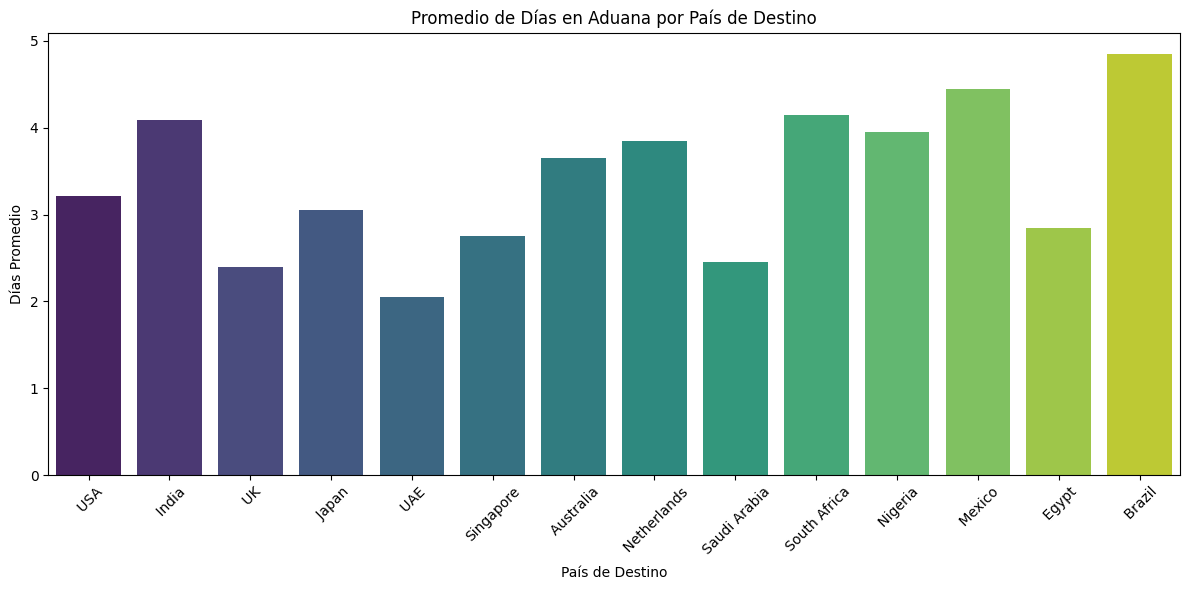

In [326]:
plt.figure(figsize=(12, 6))
# Calculamos la media automática con barplot
sns.barplot(data=shipment, x='d_country', y='customs_clearance_time_days', errorbar=None, palette='viridis')
plt.xticks(rotation=45)
plt.title('Promedio de Días en Aduana por País de Destino')
plt.xlabel('País de Destino')
plt.ylabel('Días Promedio')
plt.tight_layout()
plt.show()

* Egypt y Brazil lideran los tiempos más altos de permanencia en aduana
* Singapore, UK y Japan demuestran ser los mas ágiles

In [328]:
url = '../data/processed/'
customer.to_csv(os.path.join(url, 'customer.csv'), index=False)
logistics.to_csv(os.path.join(url, 'logistics.csv'), index=False)
shipment.to_csv(os.path.join(url, 'shipment.csv'), index=False)

print(f'exitoso')


exitoso
